# Motor Insurance Pricing — Severity Frequency Modeling

**Goal of this notebook:** To predict the expected severity of claims (`ClaimAmount`) for policies that actually had a claim. I know from the EDA that `ClaimAmount` is heavily right-skewed, continuous and strictly positive, so i will likely use a Gamma regression or Lognormal model. 

**Steps:**
1. Target variable exploration: revisit ClaimAmount, now specifically for Gamma-model suitability
2. Feature preparation: same features as before, but only for the subset of policies with claims
3. Baseline Gamma GLM
4. Check model assumptions
5. Model comparison (e.g. Gamma vs Lognormal)
6. Summary of findings

## 0. Setup
##### Note:
We merge only the rows in the severity and frequency datasets which contain an `IDpol`. This is important for our analysis because we want to make sure that we are only analyzing the severity data for policies that also have frequency data available. This is done using an inner join, and we can expect 195 fewer rows in the merged data compared to the unmerged data, as expected previously in the EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

DATA_DIR = "../data/processed"

freq = pd.read_csv(f"{DATA_DIR}/freMTPL2freq_clean.csv")
sev = pd.read_csv(f"{DATA_DIR}/freMTPL2sev_clean.csv")

sev_merged = sev.merge(freq, on="IDpol", how="inner")

print("sev shape (before merge):", sev.shape)
print("sev_merged shape (after merge):", sev_merged.shape)

sev shape (before merge): (26639, 2)
sev_merged shape (after merge): (26444, 15)


## 1. Target Variable Exploration

I want to check if `ClaimAmount` is suitable for modelling via a Gamma distribution. Gamma distributions are specifically designed for heavily right-skewed, only positive data. `ClaimAmount` satisfies these conditions as found in the EDA. Another assumption to check is if the coefficient of variation (standard deviation divided by the mean) is roughly constant across observations.

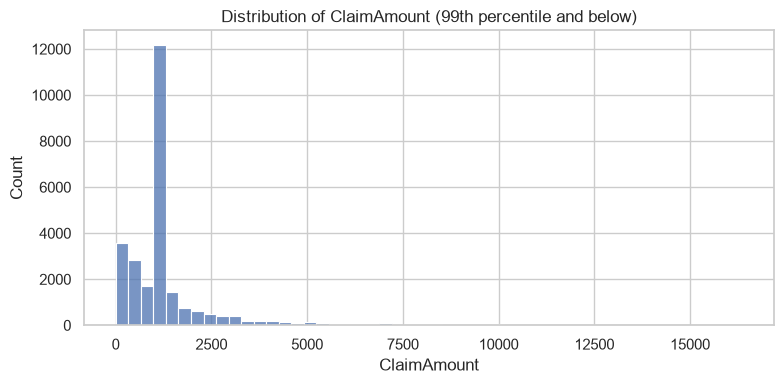

Min ClaimAmount: 1.0
Rows with ClaimAmount <= 0: 0
Skewness: 109.52986466339235
Skewness (99th percentile and below): 4.24232801354772


In [2]:
# Graph from EDA Univariate Analysis

xlim_val = sev_merged["ClaimAmount"].quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(sev_merged[sev_merged["ClaimAmount"] <= xlim_val]["ClaimAmount"], bins=50, ax=ax)
ax.set_title("Distribution of ClaimAmount (99th percentile and below)")
plt.tight_layout()
plt.show()

# Check for zero/negative values
print("Min ClaimAmount:", sev_merged["ClaimAmount"].min())
print("Rows with ClaimAmount <= 0:", (sev_merged["ClaimAmount"] <= 0).sum())
print("Skewness:", sev_merged["ClaimAmount"].skew())

# Skewness excluding the most extreme outliers, for comparison
capped = sev_merged[sev_merged["ClaimAmount"] <= sev_merged["ClaimAmount"].quantile(0.99)]
print("Skewness (99th percentile and below):", capped["ClaimAmount"].skew())


##### Findings:

This analysis showcases a very interesting result. We can see from the minimum claim amount and the rows with claim amounts less than or equal to 0 that the values in the dataset are strictly positive, thus suitable for Gamma distribution. Initially, the skewness value is also extremely high at roughly 109.53. However it is important to consider that the initial skewness calculation uses the values from the top 1%, which I had previously excluded from the graph as otherwise the plot is dominated by the extreme values. After removing the top 1% and recaluclating the skewness, we get a much more reasonable skewness value of 4.24, still quite right-skewed but far more representative of the bulk of the data, however not overly so. For this reason, the extreme outlier(s) identified here may need special handling such as capping, or reviewing whether it should be modelled as a separate large-loss category as Gamma regression can be sensitive to them.

## 2. Feature preparation

### 2a. Choose features and encode categories

I will group rare categories that were identified in the 01_data_exploration notebook into "Other" before encoding, so the model has enough claims to estimate what a typical claim size looks like for that category.

In [3]:
sev_merged["VehBrand"].value_counts()

VehBrand
B1     6898
B2     6805
B12    4200
B3     2429
B5     1662
B6     1252
B4     1099
B10     765
B11     664
B13     539
B14     131
Name: count, dtype: int64

In [4]:
sev_merged["Region"].value_counts()

Region
Centre                         6475
Rhone-Alpes                    4233
Provence-Alpes-Cotes-D'Azur    2986
Ile-de-France                  2591
Bretagne                       1871
Pays-de-la-Loire               1576
Nord-Pas-de-Calais             1412
Languedoc-Roussillon           1068
Aquitaine                      1055
Poitou-Charentes                800
Basse-Normandie                 452
Midi-Pyrenees                   369
Bourgogne                       345
Picardie                        314
Haute-Normandie                 220
Limousin                        197
Auvergne                        141
Corse                           132
Alsace                           92
Champagne-Ardenne                77
Franche-Comte                    38
Name: count, dtype: int64

In [5]:
MIN_CATEGORY_COUNT = 1000 # I again picked this value to ensure that each category has enough claims to estimate what a typical claim size looks like for that category.
for col in ["VehBrand", "Region"]:
    counts = sev_merged[col].value_counts()
    rare = counts[counts < MIN_CATEGORY_COUNT].index
    sev_merged[col] = sev_merged[col].where(~sev_merged[col].isin(rare), "Other")
    print(f"{col}: grouped {len(rare)} rare categories into 'Other'")

VehBrand: grouped 4 rare categories into 'Other'
Region: grouped 12 rare categories into 'Other'


In [6]:
feature_cols = ["VehPower", "VehAge_capped", "DrivAge_capped", "BonusMalus", "VehBrand", "VehGas", "Area", "Region", "Density"]

model_df = sev_merged[feature_cols + ["ClaimAmount"]].copy()

# log-transform Density (heavily right-skewed, per EDA findings)
model_df["log_Density"] = np.log(model_df["Density"])
model_df = model_df.drop(columns="Density")

model_df.head()

,VehPower,VehAge_capped,DrivAge_capped,BonusMalus,VehBrand,VehGas,Area,Region,ClaimAmount,log_Density
0,11,0,39,56,B12,Diesel,D,Other,995.20,6.656727
1,4,1,49,50,B12,Regular,E,Ile-de-France,1128.12,7.763871
2,4,2,32,106,B12,Regular,D,Nord-Pas-de-Calais,1851.11,6.345636
3,4,1,49,57,B12,Regular,C,Other,1204.00,5.662960
4,12,0,37,50,B12,Diesel,F,Ile-de-France,1204.00,10.203592


### 2b. Handle the extreme outlier(s)

I have chosen to cap the Claim Amounts to the 99.5th percentile and below to tame the extreme outlier(s) without throwing away too much genuine information about the largest normal claims.

In [7]:
n_over = (sev_merged["ClaimAmount"].quantile(0.995) < sev_merged["ClaimAmount"]).sum()
print(f"Capping {n_over} rows with ClaimAmount > {sev_merged['ClaimAmount'].quantile(0.995)}")

sev_merged["ClaimAmount"] = sev_merged["ClaimAmount"].clip(upper=sev_merged["ClaimAmount"].quantile(0.995))

# Check the quantiles of ClaimAmount to verify capping
print(sev_merged["ClaimAmount"].quantile(0.995))
print(sev_merged["ClaimAmount"].quantile(0.999))
print(sev_merged["ClaimAmount"].quantile(0.9999)) #As there is no significant difference between 99.9% and 99.99% quantiles, we can conclude that capping at 99.5% is reasonable.

Capping 133 rows with ClaimAmount > 34376.964349999944
34309.30076474991
34376.964349999944
34376.964349999944


### 2c. Train/test split

In [8]:
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (21155, 10)
Test shape: (5289, 10)


## 3. Baseline Gamma GLM

Unlike the claim frequency modelling notebook, there is no need for an exposure offset in the Gamma GLM. This is because the Exposure offset was used to control how much time did this policy have to generate a claim. However when it comes to claim severity, that concept doesn't apply once you're only looking at claims that already happened. 

Similarly to the Poisson GLM I used in my claim frequency modelling, I used a log link to guarantee that my weighted sum outputted a positive number, in order to predict claim amounts. However, in statsmodels the Gamma GLM has a default "inverse link", which while it can also work is a lot less intuitive and harder to explain. With a log link instead, there is a product of multiplicative factors, one per feature. This means each coefficient has a clean, story-friendly interpretation. This is also useful as it will allow for the calculation of frequency x severity to be a much more natural multiplication of similarly-structured models.

In [ ]:
formula = ( "ClaimAmount ~ VehPower + VehAge_capped + DrivAge_capped + BonusMalus " "+ C(VehBrand) + C(VehGas) + C(Area) + C(Region) + log_Density" )

gamma_model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(gamma_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                21155
Model:                            GLM   Df Residuals:                    21127
Model Family:                   Gamma   Df Model:                           27
Link Function:                    Log   Scale:                          50.633
Method:                          IRLS   Log-Likelihood:            -2.2999e+05
Date:                Thu, 13 Aug 2026   Deviance:                       35491.
Time:                        22:15:21   Pearson chi2:                 1.07e+06
No. Iterations:                    58   Pseudo R-squ. (CS):           0.002726
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

##### Findings:

This model has produced incredibly interesting results. The Gamma model shows very weak explanatory power (Pseudo R² = 0.0027). Furthermore, most of the risk features have a p value greater than 0.05, thus their coefficents are not statistically significant. The few exceptions include Vehicle Gas (borderline, p=0.040) and BonusMalus (p=0.016) showing any signal, with small effect sizes. This is quite different what I experienced with my frequency model, where several features were clearly significant. This is consistent with actuarial theory which states that claim frequency tends to be driven by policyholder **risk profile**, while claim severity is often driven more by the **nature** of the specific accident. This is also consistent with the EDA finding that a large share of claims follow standardized IRSA-IDA flat payout amounts. This is a factor unrelated to any policyholder characteristic, which would naturally limit how much these risk features can explain about claim size. 



## 4. Checking model assumptions

The core assumption for Gamma regression is different from Poisson's "mean = variance" rule. Gamma assumes that variance is proportional to the **mean squared**. In other words, the **coefficient of variation** which is equal to standard deviation ÷ mean should be roughly constant across observations, regardless of whether the predicted claim is small or large.

In [10]:
pearson_chi2 = gamma_model.pearson_chi2
df_resid = gamma_model.df_resid
dispersion_ratio = pearson_chi2 / df_resid

print(f"Pearson chi2:      {pearson_chi2:.2f}")
print(f"Degrees of freedom: {df_resid:.0f}")
print(f"Dispersion ratio:   {dispersion_ratio:.3f}")

Pearson chi2:      1069728.99
Degrees of freedom: 21127
Dispersion ratio:   50.633
